In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import LabelEncoder



### zadanie 1

In [ ]:
def linear_regression_ols(x, y):
    X = np.column_stack([np.ones(len(x)), x])
    coefficients = np.linalg.inv(X.T @ X) @ X.T @ y
    return coefficients[0], coefficients[1]

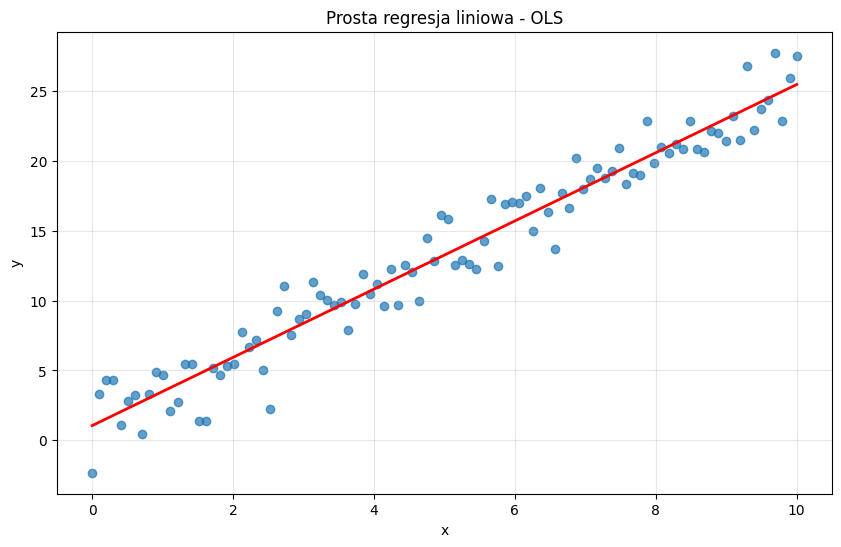

In [ ]:
x = np.linspace(0, 10, 100)
true_slope = 2.5
true_intercept = 1.0
y = true_slope * x + true_intercept + np.random.normal(0, 1.5, 100)

intercept, slope = linear_regression_ols(x, y)
y_pred = slope * x + intercept

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, y_pred, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Prosta regresja liniowa - OLS')
plt.grid(True, alpha=0.3)
plt.show()

### zadanie 2

In [ ]:
x = np.linspace(0, 10, 100)
true_slope = 2.5
true_intercept = 1.0
y = true_slope * x + true_intercept + np.random.normal(0, 1.5, 100)

intercept_custom, slope_custom = linear_regression_ols(x, y)

x_sklearn = x.reshape(-1, 1)
model_sklearn = LinearRegression()
model_sklearn.fit(x_sklearn, y)

print("Porównanie współczynników:")
print(f"Własna implementacja: intercept = {intercept_custom:.4f}, slope = {slope_custom:.4f}")
print(f"Scikit-learn: intercept = {model_sklearn.intercept_:.4f}, slope = {model_sklearn.coef_[0]:.4f}")


Porównanie współczynników:
Własna implementacja: intercept = 1.2569, slope = 2.4633
Scikit-learn: intercept = 1.2569, slope = 2.4633


In [ ]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

model = LinearRegression()
model.fit(X, y)

print(f"\nRegresja wielokrotna - California Housing:")
print(f"Liczba cech: {X.shape[1]}")
print("\nWspółczynniki modelu:")
for name, coef in zip(housing.feature_names, model.coef_):
    print(f"{name}: {coef:.6f}")
print(f"Intercept: {model.intercept_:.4f}")


Regresja wielokrotna - California Housing:
Liczba cech: 8

Współczynniki modelu:
MedInc: 0.436693
HouseAge: 0.009436
AveRooms: -0.107322
AveBedrms: 0.645066
Population: -0.000004
AveOccup: -0.003787
Latitude: -0.421314
Longitude: -0.434514
Intercept: -36.9419


### zadanie 3

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Metryki oceny modelu regresji:")
print(f"MSE (średni błąd kwadratowy): {mse:.4f}")
print(f"RMSE (pierwiastek błędu kwadratowego): {rmse:.4f}")
print(f"MAE (średni błąd bezwzględny): {mae:.4f}")
print(f"R² (współczynnik determinacji): {r2:.4f}")

print("\nInterpretacja:")
print("MSE - średni kwadrat różnicy między przewidywaniami a rzeczywistymi wartościami")
print("RMSE - błąd w tych samych jednostkach co zmienna docelowa (ceny domów)")
print("MAE - średnia wartość bezwzględna błędów predykcji")
print("R² - procent wyjaśnionej wariancji (0-1, im bliżej 1 tym lepiej)")

Metryki oceny modelu regresji:
MSE (średni błąd kwadratowy): 0.5559
RMSE (pierwiastek błędu kwadratowego): 0.7456
MAE (średni błąd bezwzględny): 0.5332
R² (współczynnik determinacji): 0.5758

Interpretacja:
MSE - średni kwadrat różnicy między przewidywaniami a rzeczywistymi wartościami
RMSE - błąd w tych samych jednostkach co zmienna docelowa (ceny domów)
MAE - średnia wartość bezwzględna błędów predykcji
R² - procent wyjaśnionej wariancji (0-1, im bliżej 1 tym lepiej)


In [ ]:
housing = fetch_california_housing()
X = housing.data[:, 0].reshape(-1, 1) 
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MSE: 0.7091
RMSE: 0.8421
MAE: 0.6299
R²: 0.4589


MSE: 0.7091 - Średni kwadrat błędu wynosi 0.7091. Oznacza to, że średnio kwadrat różnicy między przewidywaną a rzeczywistą ceną domu to ~0.71.

RMSE: 0.8421 - Średni błąd wynosi ~0.84. Ponieważ ceny są w setkach tysięcy dolarów, oznacza to, że model średnio myli się o $84,210.

MAE: 0.6299 - Średni błąd bezwzględny to ~0.63, czyli średnio model myli się o $62,990.

R²: 0.4589 - Model wyjaśnia 45.89% wariancji cen domów. Oznacza to, że dochód (MedInc) tłumaczy niecałą połowę zmienności cen - reszta zależy od innych czynników.

### zadanie 4

In [ ]:
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 2.5 * x + 1.0 + np.random.normal(0, 1.5, 100)

x_noisy = x + np.random.normal(0, 0.5, 100)
y_noisy = y + np.random.normal(0, 2, 100)

X = x_noisy.reshape(-1, 1)

lr = LinearRegression()
ridge = Ridge(alpha=0.1)
lasso = Lasso(alpha=0.1)

lr.fit(X, y_noisy)
ridge.fit(X, y_noisy)
lasso.fit(X, y_noisy)

print("Współczynniki:")
print(f"Linear: intercept={lr.intercept_:.3f}, slope={lr.coef_[0]:.3f}")
print(f"Ridge: intercept={ridge.intercept_:.3f}, slope={ridge.coef_[0]:.3f}")
print(f"Lasso: intercept={lasso.intercept_:.3f}, slope={lasso.coef_[0]:.3f}")

Współczynniki:
Linear: intercept=1.575, slope=2.375
Ridge: intercept=1.576, slope=2.374
Lasso: intercept=1.632, slope=2.363


### zadanie 5

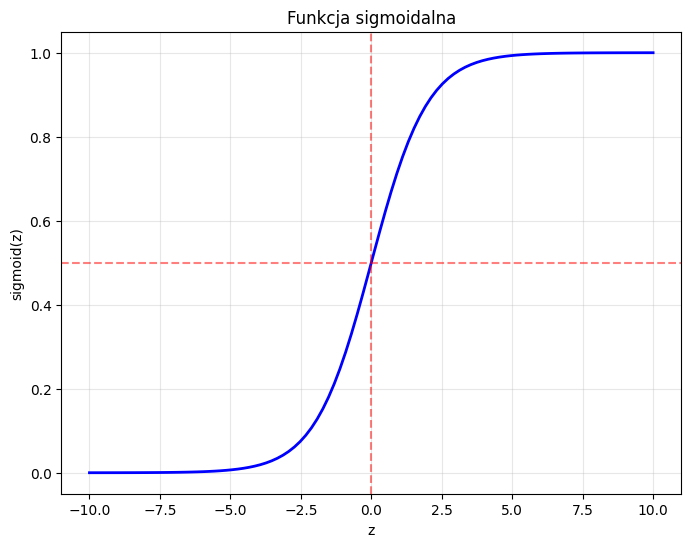

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
y = sigmoid(z)

plt.figure(figsize=(8, 6))
plt.plot(z, y, 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Funkcja sigmoidalna')
plt.grid(True, alpha=0.3)
plt.show()

Rola funkcji sigmoidalnej w regresji logistycznej:
Funkcja sigmoidalna przekształca liniową kombinację cech na prawdopodobieństwo między 0 a 1. Działa jak miękki próg decyzyjny - wartości powyżej 0.5 klasyfikujemy jako klasę 1, poniżej jako klasę 0.

Dlaczego jest używana w klasyfikacji binarnej:
Zamienia dowolne wartości rzeczywiste na interpretowalne prawdopodobieństwa
Jej kształt "S" idealnie modeluje przejście między klasami
Jest różniczkowalna, co umożliwia uczenie gradientowe

### zadanie 6

In [ ]:
titan = pd.read_csv("../data/titan.csv")

data = titan[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
data = data.dropna()

le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
data['Embarked'] = le.fit_transform(data['Embarked'])

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### zadanie 7

Dokładność: 0.797
Precyzja: 0.854
Czułość: 0.651


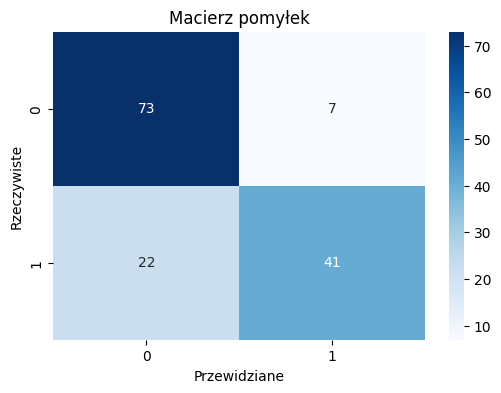


Macierz pomyłek:
[[73  7]
 [22 41]]

TN: 73, FP: 7
FN: 22, TP: 41


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Dokładność: {accuracy:.3f}")
print(f"Precyzja: {precision:.3f}")
print(f"Czułość: {recall:.3f}")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Macierz pomyłek')
plt.ylabel('Rzeczywiste')
plt.xlabel('Przewidziane')
plt.show()

print("\nMacierz pomyłek:")
print(conf_matrix)
print(f"\nTN: {conf_matrix[0][0]}, FP: {conf_matrix[0][1]}")
print(f"FN: {conf_matrix[1][0]}, TP: {conf_matrix[1][1]}")

Model osiągnął dokładność 79.7%, co oznacza że poprawnie przewiduje przeżycie w około 4 na 5 przypadków. Precyzja na poziomie 85.4% wskazuje, że gdy model przewiduje przeżycie, ma bardzo wysoką szansę trafienia. Jednak czułość 65.1% pokazuje, że model przeocza znaczną część prawdziwych ocalałych - około jednej trzeciej osób które przeżyły nie zostało wykrytych. Analizując macierz pomyłek widać, że model lepiej radzi sobie z identyfikacją ofiar (73 poprawne) niż ocalałych (41 poprawne), przy czym stosunkowo rzadko daje fałszywe nadzieje (tylko 7 przypadków), ale niestety pomija 22 osoby które rzeczywiście przeżyły.
